In [1]:
!pip install facenet_pytorch
!pip install --upgrade scipy scikit-learn
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import os
import cv2
from facenet_pytorch import MTCNN
from PIL import Image
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- 1. PROFESSIONAL ViT ARCHITECTURE ---
class VideoDeepfakeModel(nn.Module):
    def __init__(self, num_classes=2):
        super(VideoDeepfakeModel, self).__init__()
        # Load pre-trained Vision Transformer
        self.model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        # Replace the classification head for Binary Classification (Fake vs Real)
        self.model.heads = nn.Sequential(
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Video Architecture Ready on {device}")

Video Architecture Ready on cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- 2. ADVANCED DATA PIPELINE ---
DATA_PATH = "/content/drive/MyDrive/data/celeb_df/processed_faces"

# 1. Training Augmentations (Force it to learn faces, not video quality)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Validation Augmentations (Clean, strict evaluation)
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if os.path.exists(DATA_PATH):
    # Load the base folder twice so we can attach the different transforms
    dataset_train_base = datasets.ImageFolder(root=DATA_PATH, transform=transform_train)
    dataset_val_base = datasets.ImageFolder(root=DATA_PATH, transform=transform_val)

    # Calculate sizes
    train_size = int(0.8 * len(dataset_train_base))
    val_size = len(dataset_train_base) - train_size

    # Generate random indices to ensure Train and Val don't overlap
    indices = torch.randperm(len(dataset_train_base)).tolist()

    # Create the final Subsets
    train_dataset = torch.utils.data.Subset(dataset_train_base, indices[:train_size])
    val_dataset = torch.utils.data.Subset(dataset_val_base, indices[train_size:])

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"Advanced Data Pipeline Loaded.")
    print(f"Class Mapping: {dataset_train_base.class_to_idx}")
    print(f"Training Images: {len(train_dataset)} | Validation Images: {len(val_dataset)}")
else:
    print(f"ERROR: Could not find dataset at {DATA_PATH}")

Advanced Data Pipeline Loaded.
Class Mapping: {'fake': 0, 'real': 1}
Training Images: 4982 | Validation Images: 1246


In [4]:
# --- 3. TRAINING ENGINE ---
import torch.optim as optim
import os
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score

def train_video_model(train_loader, val_loader, epochs=30, patience=5):
    print("Initializing Professional Training Engine...")
    model = VideoDeepfakeModel(num_classes=2).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

    BEST_MODEL_PATH = '/content/drive/MyDrive/data/celeb_df/models/best_video_detector.pth'
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

    best_val_loss = float('inf')
    early_stop_counter = 0

    print(f"\n{'Epoch':<5} | {'TrL':<6} | {'VaL':<6} | {'Acc':<6} | {'AUC':<6} | {'Status'}")
    print("-" * 55)

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0

        # We use a silent tqdm here to avoid flooding the output, keeping it clean
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Prevent exploding gradients
            optimizer.step()
            train_loss += loss.item()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        all_labels = []
        all_probs = []
        all_preds = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Get probabilities for Class 1 (usually 'Real')
                probs = torch.softmax(outputs, dim=1)[:, 1]
                preds = torch.argmax(outputs, dim=1)

                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        # --- METRICS CALCULATION ---
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        acc = accuracy_score(all_labels, all_preds)

        # Protect against single-class batches in AUC calculation
        try:
            auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            auc = 0.5

        # --- EARLY STOPPING & CHECKPOINTING ---
        status = ""
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            status = "Best Saved"
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            status = f"Wait {early_stop_counter}/{patience}"

        # Print cleanly formatted epoch summary
        print(f"{epoch+1:<5} | {avg_train_loss:<6.3f} | {avg_val_loss:<6.3f} | {acc*100:<5.1f}% | {auc:<6.3f} | {status}")

        if early_stop_counter >= patience:
            print("\nEarly stopping triggered. Training Complete.")
            print(f"Best model weights safely stored at: {BEST_MODEL_PATH}")
            break

# Execute the training
train_video_model(train_loader, val_loader, epochs=30, patience=5)

🚀 Initializing Professional Training Engine...


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:03<00:00, 107MB/s]



Epoch | TrL    | VaL    | Acc    | AUC    | Status
-------------------------------------------------------
1     | 0.322  | 0.313  | 90.8 % | 0.704  | Best Saved
2     | 0.315  | 0.304  | 90.8 % | 0.596  | Best Saved
3     | 0.313  | 0.291  | 90.8 % | 0.695  | Best Saved
4     | 0.309  | 0.285  | 90.8 % | 0.761  | Best Saved
5     | 0.305  | 0.280  | 90.8 % | 0.754  | Best Saved
6     | 0.293  | 0.267  | 90.9 % | 0.792  | Best Saved
7     | 0.286  | 0.277  | 91.1 % | 0.781  | Wait 1/5
8     | 0.270  | 0.250  | 91.2 % | 0.816  | Best Saved
9     | 0.258  | 0.212  | 92.7 % | 0.877  | Best Saved
10    | 0.237  | 0.210  | 92.3 % | 0.889  | Best Saved
11    | 0.220  | 0.246  | 91.4 % | 0.888  | Wait 1/5
12    | 0.199  | 0.183  | 93.3 % | 0.911  | Best Saved
13    | 0.198  | 0.203  | 91.6 % | 0.920  | Wait 1/5
14    | 0.179  | 0.230  | 93.0 % | 0.902  | Wait 2/5
15    | 0.177  | 0.171  | 93.3 % | 0.936  | Best Saved
16    | 0.159  | 0.230  | 89.6 % | 0.945  | Wait 1/5
17    | 0.164  | 0.178

Loading weights for evaluation...


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 157MB/s]
Evaluating: 100%|██████████| 39/39 [03:19<00:00,  5.11s/it]


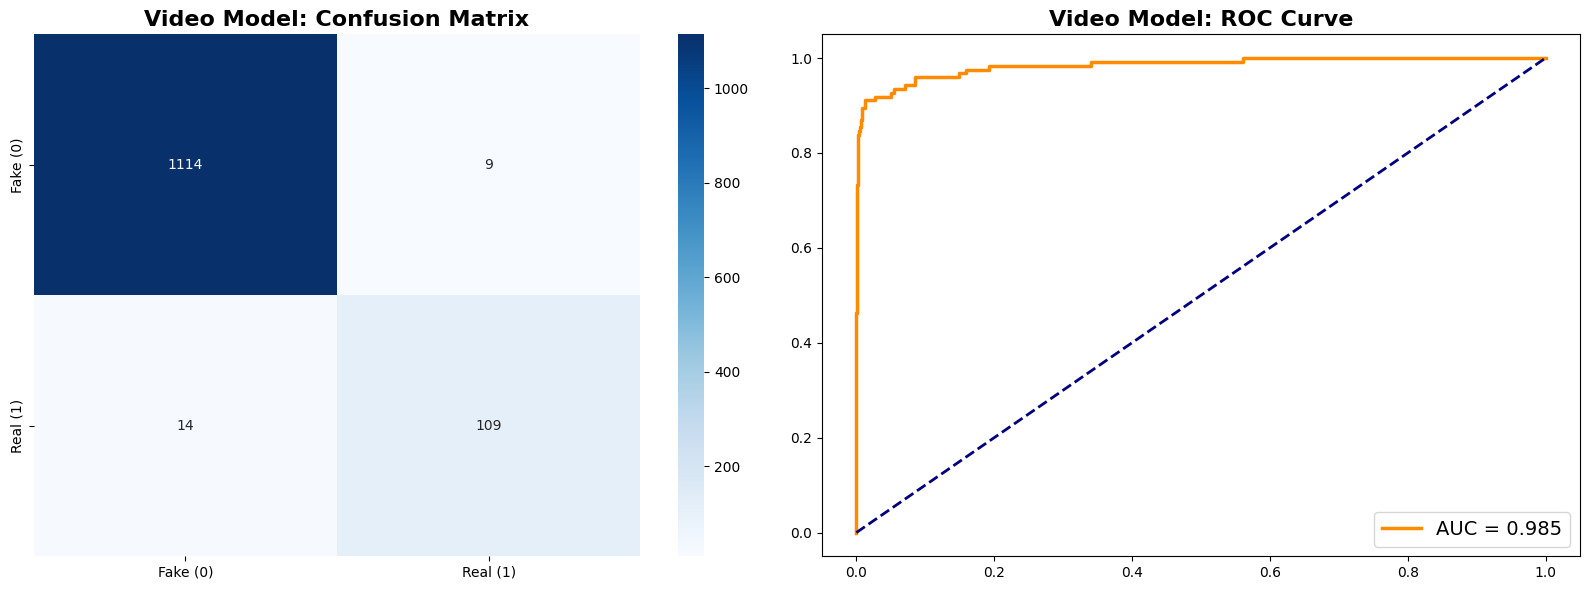

Graph saved to: /content/drive/MyDrive/data/celeb_df/video_evaluation_plots.png


In [4]:
# --- 3. EVALUATION METRICS (ROC & CONFUSION MATRIX) ---
def evaluate_video_model(model_path, val_loader):
    print("Loading weights for evaluation...")
    model = VideoDeepfakeModel(num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            # Softmax to get probabilities (Class 1 is Real)
            probs = torch.softmax(logits, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob > 0.5).astype(int)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Fake (0)', 'Real (1)'], yticklabels=['Fake (0)', 'Real (1)'])
    axes[0].set_title('Video Model: Confusion Matrix', fontsize=16, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('Video Model: ROC Curve', fontsize=16, fontweight='bold')
    axes[1].legend(loc="lower right", fontsize=14)

    plt.tight_layout()
    SAVE_PATH = '/content/drive/MyDrive/data/celeb_df/video_evaluation_plots.png'
    plt.savefig(SAVE_PATH, dpi=300)
    plt.show()
    print(f"Graph saved to: {SAVE_PATH}")

evaluate_video_model('/content/drive/MyDrive/data/celeb_df/models/best_video_detector.pth', val_loader)

In [5]:
%%bash
# 1. Define where to save the video in your Google Drive
SAVE_PATH="/content/drive/MyDrive/data/celeb_df/test_video.mp4"

# 2. Download a reliable, open-source sample face video (from Intel's IoT sample repository)
wget -O "$SAVE_PATH" "https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/face-demographics-walking.mp4"

echo "Video successfully downloaded to: $SAVE_PATH"

Video successfully downloaded to: /content/drive/MyDrive/data/celeb_df/test_video.mp4


--2026-02-26 18:47:52--  https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/face-demographics-walking.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6406124 (6.1M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/data/celeb_df/test_video.mp4’

     0K .......... .......... .......... .......... ..........  0% 11.5M 1s
    50K .......... .......... .......... .......... ..........  1% 11.1M 1s
   100K .......... .......... .......... .......... ..........  2% 39.1M 0s
   150K .......... .......... .......... .......... ..........  3% 57.0M 0s
   200K .......... .......... .......... .......... ..........  3% 17.0M 0s
   250K .......... .......... .......... .......... ..........  4% 46.0M 0s
   300K .......... ..........

In [6]:
# =========================================================
# VIDEO DEEPFAKE TESTER PROGRAM
# =========================================================
import cv2
import torch
import os
from PIL import Image
from facenet_pytorch import MTCNN
from torchvision import transforms

def test_video_file(video_path, model_path):
    print("="*50)
    print(f"SCANNING VIDEO: {os.path.basename(video_path)}")
    print("="*50)

    # 1. Check if files exist
    if not os.path.exists(video_path):
        return print(f"ERROR: Cannot find video at {video_path}")
    if not os.path.exists(model_path):
        return print(f"ERROR: Cannot find model weights at {model_path}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 2. Load the Model Architecture & Weights
    model = VideoDeepfakeModel(num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    print("ViT Model Loaded Successfully.")

    # 3. Initialize Face Extractor (MTCNN)
    mtcnn = MTCNN(margin=40, keep_all=False, post_process=False, device=device)

    # 4. Define the exact same normalization used in validation
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 5. Process the Video (Sample 10 frames evenly)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return print("ERROR: Video is empty or corrupted.")

    interval = max(1, total_frames // 10)
    face_probs = []

    print("Extracting and analyzing faces...")
    for i in range(10):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        success, frame = cap.read()
        if not success: continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Detect Face
        face_tensor = mtcnn(Image.fromarray(frame_rgb))

        if face_tensor is not None:
            # Convert MTCNN output back to PIL image to pass to our ViT transforms
            face_np = face_tensor.permute(1, 2, 0).byte().cpu().numpy()
            face_transformed = val_transform(Image.fromarray(face_np)).unsqueeze(0).to(device)

            # Get Prediction
            with torch.no_grad():
                logits = model(face_transformed)
                # Softmax gives us [Prob_Fake, Prob_Real]
                prob_real = torch.softmax(logits, dim=1)[:, 1].item()
                face_probs.append(prob_real)

    cap.release()

    # 6. Final Decision Logic
    if len(face_probs) == 0:
        return print("NO FACES DETECTED IN THIS VIDEO.")

    avg_prob = sum(face_probs) / len(face_probs)

    print("\n" + "="*50)
    if avg_prob > 0.5:
        confidence = avg_prob * 100
        print(f"FINAL DECISION: GENUINE (REAL)")
        print(f"CONFIDENCE:   {confidence:.2f}%")
    else:
        confidence = (1 - avg_prob) * 100
        print(f"FINAL DECISION: DEEPFAKE (FAKE)")
        print(f"CONFIDENCE:   {confidence:.2f}%")
    print("="*50 + "\n")


MODEL_WEIGHTS = '/content/drive/MyDrive/data/celeb_df/models/best_video_detector.pth'
TEST_VIDEO = '/content/drive/MyDrive/data/celeb_df/test_video.mp4'
test_video_file(TEST_VIDEO, MODEL_WEIGHTS)

SCANNING VIDEO: test_video.mp4
ViT Model Loaded Successfully.
Extracting and analyzing faces...

FINAL DECISION: GENUINE (REAL)
CONFIDENCE:   88.50%

